# Sommario del Caso B
Buongiorno, il team "Python for California" si compone di 4 studenti: Elisabetta Errighi, Lorenzo Frascarelli, Lorenzo Bracci e Stefano Sacchi.
Il caso che analizziamo prevede un'analisi esplorativa sulle determinanti dei prezzi del mercato immobiliare californiano con un modello di regressione che mira a stimare l'impatto congiunto delle caratteristiche strutturali, socio-economiche e geografiche sul valore degli immobili

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt

#  Il Dataset: Caricamento descrizione e pulizia

In [ ]:
url_dati =  "https://www.kaggle.com/datasets/camnugent/california-housing-prices"

In [ ]:
dati = pd.read_csv('housing.csv', sep=',')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dati.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
dati.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
print(dati.shape)

(20640, 10)


In [ ]:
dati.isna().sum()  #tramite questo comando controllo se nel dataframe sono in presenza di dati mancanti

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
dati = dati.dropna() # Il comando elimina i dati mancanti

In [ ]:
dati.isna().sum() #rieseguendo il codice precedente possiamo osservare come in questo caso non siamo più in presenza di dati mancanti

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Abbiamo provveduto a eliminare i dati mancanti in quanto tali dati rispetto al numero totale rappresentano una quota minima, pertanto abbiamo ritenuto che distorcesse meno l'analisi la loro eliminazione rispetto alla sostituzione con moda o mediana in quanto inferiori al 5% dei dati totali. Infatti, sono solo 207 su 20.640 che corrisponde circa all'1%

In [ ]:
dati.duplicated().sum() #tramite questo comando vado a vedere se nel dataset sono presenti dati duplicati

np.int64(0)

Non siamo in presenza di dati duplicati perciò significa che nel nostro dataset non c'è neanche una riga che equivale all'altra in tutte le colonne. Tale risultato è positivo in quanto i dati duplicati vanno a falsare le analisi e i grafici e tendenzialmente sono sintomo di dati raccolti in un modo sbagliato

# Analisi Esplorativa

In [ ]:
dati.describe(include='all') #tramite questo comando sono in grado di osservare tutte le metodologie di analisi statistica di base.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9034
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,NaN
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,NaN
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,NaN


Osservando l'output generato dal comando precedente posso osservare come relativamente alla variabile "house median value" il salto tra il 75° percentile (264k) e il max (500k) è molto significativo. Questo potrebbe essere un primo segnale che il valore massimo non è un "naturale" estremo della distribuzione ma un tetto imposto.

Lo stesso vale osservandi la variabile house median age.

Tramite tale analisi possiamo presupporre che entrambe le categorie rappresentino degli outlier artificiali per cui tutte le case con un valore superiore a 500k o/e con eta da 52 anni siano state ancorate a tali cifre.

Se tali outlier non venissero sistemati andrebbe a distorcere le analisi.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

<Axes: ylabel='Frequency'>

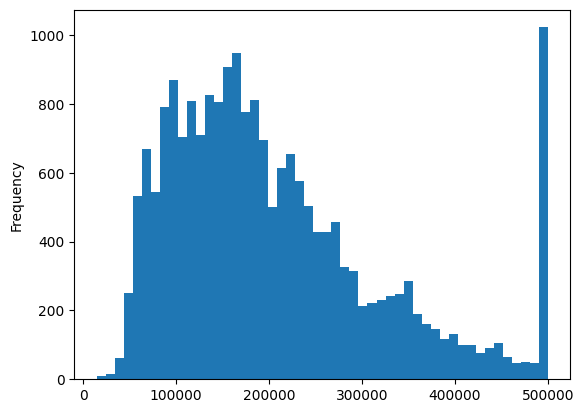

In [ ]:
dati['median_house_value'].plot.hist(bins=50)

<Axes: ylabel='Density'>

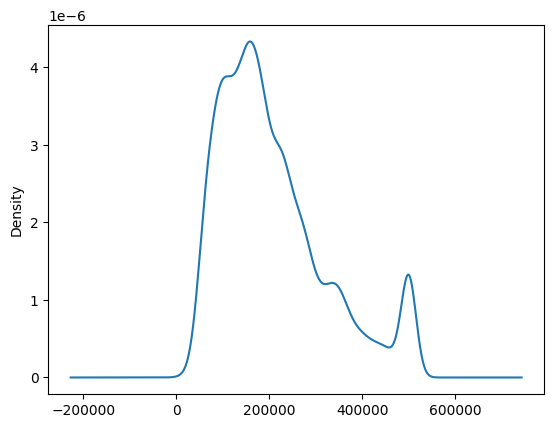

In [ ]:
dati['median_house_value'].plot.density()

Da un analisi preliminare posso notare che la distribuzione del prezzo (dopo rimozione del cap) è **asimmetrica verso destra**:
la maggior parte delle case si concentra tra 100.000 e 250.000 dollari, con una
coda lunga verso prezzi più alti. La mediana è intorno ai 180.000 dollari, quindi
sensibilmente inferiore alla media.

Come possiamo vedere dai due grafici precedenti c'è un picco in corrispondenza di 500001. Ciò conferma la nostra supposizione che in corrispondezna di tale livello siamo in presenza di un outlier artificiale. Si può affermare lo stesso per la categoria median house age come osservato nel grafico sottostante

<Axes: ylabel='Frequency'>

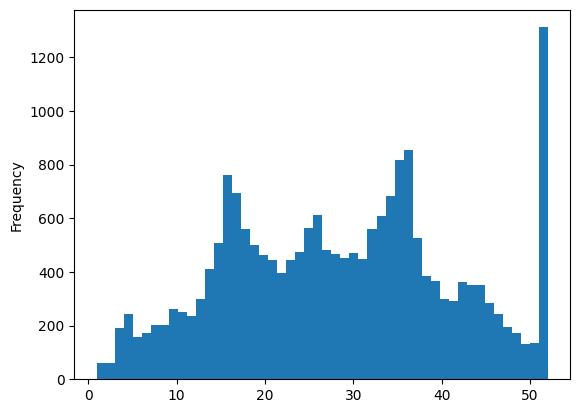

In [ ]:
dati['housing_median_age'].plot.hist(bins=50)
#costruisco istogramma riferito alla variabile housing median age e noto che c'è un picco in corrispondenza di 52

In [ ]:
dati.select_dtypes("number").corr()["median_house_value"].sort_values(ascending=False) #andiamo ad analizzare la correlazione con la variabile dipendente

,median_house_value
median_house_value,1.000000
median_income,0.688355
total_rooms,0.133294
housing_median_age,0.106432
households,0.064894
total_bedrooms,0.049686
population,-0.025300
longitude,-0.045398
latitude,-0.144638


In [ ]:
dati[["longitude", "latitude", "housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]].corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000


Analizzando la matrice di correlazione sono in grado di dedurre questo:


- median income (0,643): il reddito mediano della zona è di gran lunga
  la variabile più correlata col prezzo. È circa 5 volte più forte della
  seconda variabile in classifica e sarà il principale driver da approfondire
  nelle visualizzazioni.

- housing_median_age (0,069): l'età della casa ha un impatto modesto
  sul prezzo. Questo conferma la nostra scelta di non eliminare le osservazioni
  con età = 52 (il cap artificiale): il loro effetto distorsivo sull'analisi è
  trascurabile.
- Le variabili total_rooms, total_bedrooms, population, households
  hanno tutte correlazioni deboli

In [ ]:
dati = dati[dati['median_house_value'] < 500001]
# con questo programma andiamo ad eliminare tutti gli "outliers artificiali"
# abbiamo pertanto eliminato tutte le case a cui in modo fittizio è stato attribuito un valore pari a 500001

<Axes: ylabel='Frequency'>

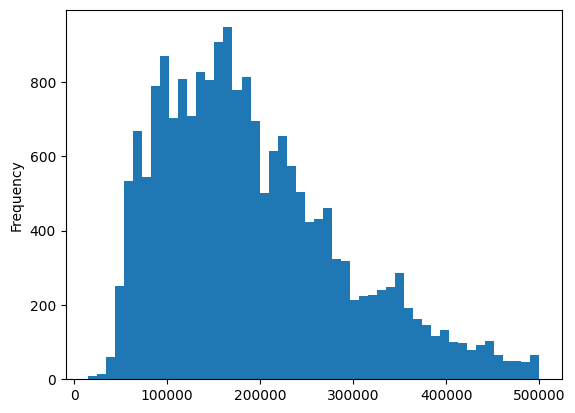

In [ ]:
dati['median_house_value'].plot.hist(bins=50)
#ora analizzando l'istogramma si nota che non è più presente il picco in corrispondenza di 500k ma che segue un andamento più a campana

Abbiamo deciso di eliminare le 965 osservazioni con prezzo pari al cap
artificiale di 500.001, perché distorcerebbero l'analisi della variabile target.
Sul cap dell'età (52 anni) preferiamo invece **non intervenire** in quanto l'età è
debolmente correlata col prezzo (ρ < 0.15), e filtrare via tutte le case
con età = 52 ci farebbe perdere il ~5% del dataset senza un beneficio analitico
proporzionato.


In [ ]:
dummies = pd.get_dummies(dati["ocean_proximity"], prefix="ocean")
#nell'campione sono presenti delle variabili destrittive per includerle vado a trasformarle in variabili dummy
dati_con_dummy = dati.join(dummies)

In [ ]:
dati_con_dummy.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_<1H OCEAN,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,False,False,False,True,False


La variabile ocean_proximity è categorica (5 valori: <1H OCEAN, INLAND,
NEAR OCEAN, NEAR BAY, ISLAND). Per poterla utilizzare nelle analisi
quantitative la trasformiamo in 5 variabili dummy

In [ ]:
# Converto le dummy in interi per includerle nella correlazione
for col in dati_con_dummy.select_dtypes("bool").columns:
    dati_con_dummy[col] = dati_con_dummy[col].astype(int)

dati_con_dummy.select_dtypes("number").corr()["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.642733
ocean_<1H OCEAN,0.285406
ocean_NEAR BAY,0.157255
total_rooms,0.142188
ocean_NEAR OCEAN,0.134585
households,0.093890
total_bedrooms,0.074672
housing_median_age,0.068595
ocean_ISLAND,0.030836


Aggiungendo le dummy alla matrice, emerge la seconda variabile
più importante dopo il reddito: `ocean_INLAND` ha correlazione −0,499 col
prezzo. Le case nell'entroterra costano
meno di tutte le altre.

Osservando le altre dummy notiamo un pattern interessante:
- `ocean_<1H OCEAN`: +0,285
- `ocean_NEAR BAY`: +0,157  
- `ocean_NEAR OCEAN`: +0,135
- `ocean_ISLAND`: +0,031
- `ocean_INLAND`: −0,499


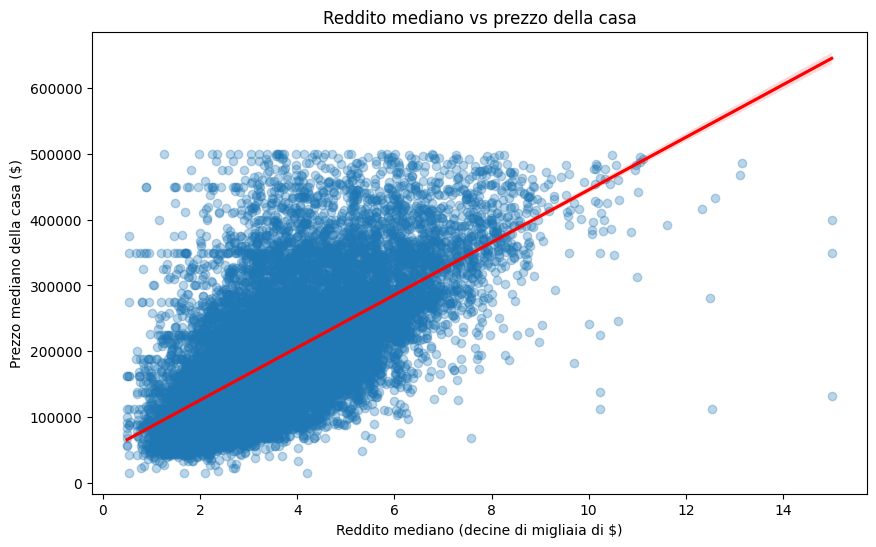

In [ ]:
plt.figure(figsize=(10,6))
sns.regplot(x="median_income", y="median_house_value", data=dati,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Reddito mediano vs prezzo della casa")
plt.xlabel("Reddito mediano (decine di migliaia di $)")
plt.ylabel("Prezzo mediano della casa ($)")
plt.show()

 Il reddito è il driver principale del prezzo

Il regplot conferma visivamente quanto emerso dalla matrice di correlazione
(ρ = 0,643): al crescere del reddito mediano del quartiere, il prezzo delle
case sale in modo chiaramente lineare. La retta di regressione (rossa)
attraversa la nuvola di punti con una pendenza marcata: passando da un reddito
di 2 a un reddito di 10 (decine di migliaia di $), il prezzo previsto sale da
circa 100.000 a oltre 500.000 dollari.

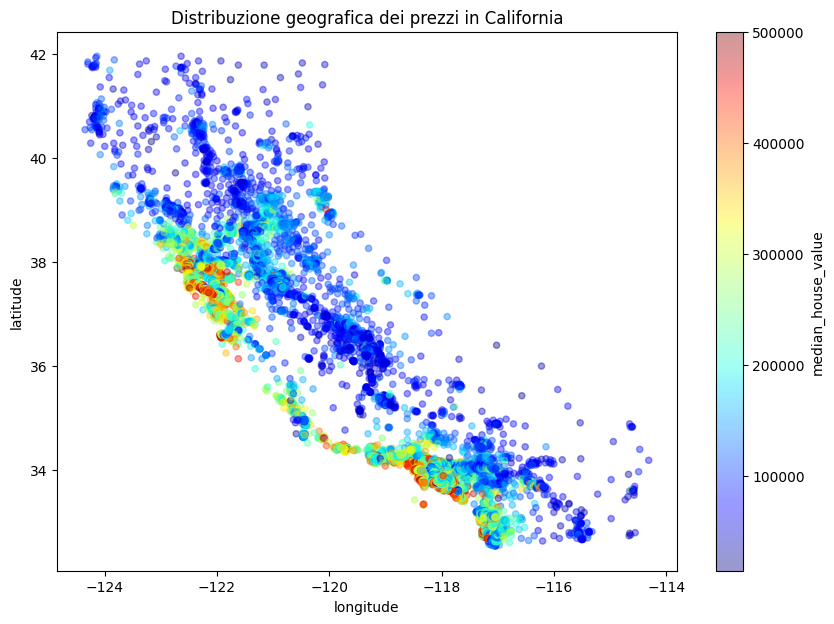

In [ ]:
dati.plot(kind="scatter", x="longitude", y="latitude",
          alpha=0.4, c="median_house_value", cmap="jet",
          colorbar=True, figsize=(10,7))
plt.title("Distribuzione geografica dei prezzi in California")
plt.show()

La geografia è il secondo grande driver del prezzo

Lo scatter geografico (longitudine sull'asse x, latitudine sull'asse y, colore
in funzione del prezzo) riproduce visivamente la sagoma della California e
rivela un pattern molto netto:

Tre cluster di prezzi alti, tutti sulla costa: probabilmente grandi città costiere.
Vaste aree di prezzi bassi nell'entroterra: plausibilmente le zone desertiche dello stato.

Questo è anche perfettamente coerente con la correlazione fortissima di
`ocean_INLAND` (−0,499): essere nell'entroterra è di per sé un forte
indicatore di prezzo basso.


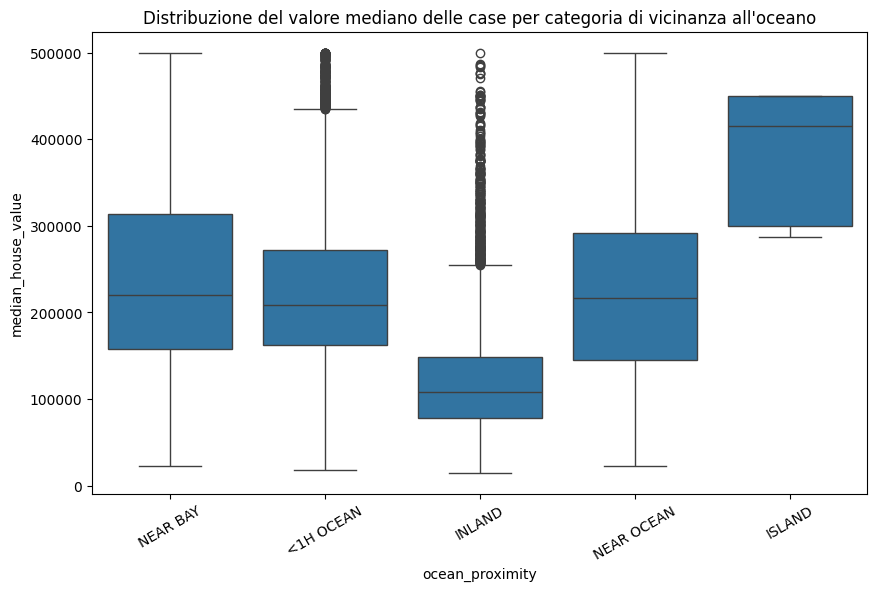

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="ocean_proximity", y="median_house_value", data=dati)
plt.title("Distribuzione del valore mediano delle case per categoria di vicinanza all'oceano")
plt.xticks(rotation=30)
plt.show()

Dal grafico emerge chiaramente un importante discrimine sul prezzo e la netta separazione tra la costa e l'entroterra

Le case nell'entroterra sono sistematicamente le più economiche del dataset, con una quotazione mediana di circa 110.000 dollari, ossia la metà rispetto alle zone costiere. La scatola dell'entroterra si trova quasi interamente al di sotto della base di tutti gli altri gruppi, i numerosi outliers in alto confermano che i prezzi alti in questa zona rappresentano solo delle eccezioni.

Al contrario, i mercati di NEAR BAY, <1H OCEAN e NEAR OCEAN sono quasi identici e sovrapponibili, con valori mediani stabili tra i 210.000 e i 230.000 dollari. Le isole  registrano i prezzi più alti in assoluto, ma la forma anomala del box e l'assenza di code indicano che il dato si basa su pochissime osservazioni.

# **Modello di regressione lineare**


In [ ]:
#importiamo le librerie che ci servono
import statsmodels.api as sm
import statsmodels.formula.api as smf
%matplotlib inline
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")


In [ ]:
dati_con_dummy2 = pd.get_dummies(dati, columns=['ocean_proximity'], drop_first=True, dtype=int) #Il comando ci consente di droppare la prima variabile dummy "<1h ocean" e risolve il problema di mantenimento del pieno rango della matrice applicando un corner constraint

In [ ]:
dati_con_dummy["ocean_proximity"].value_counts() #contiamo quante volte si ripete ciascuna dummy, notiamo che la variabile eliminata era quella più presente nel dataset originale con dummies, non sparisce dal modello ma viene considerata nell'intercetta


,count
ocean_proximity,
<1H OCEAN,8505
INLAND,6469
NEAR OCEAN,2419
NEAR BAY,2077
ISLAND,5


In [ ]:
dati_con_dummy2.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [ ]:
#definiamo la variabile dipendente che vogliamo studiare y, in questo caso "median_house_value" e le variabili indipendenti x
X=dati_con_dummy2.drop(["median_house_value"], axis=1)
Y=dati_con_dummy2["median_house_value"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42) #vogliamo verificare l'assenza di overfitting
model=LinearRegression().fit(x_train, y_train)
print(model.score(x_train, y_train))
print(model.score(x_test, y_test))

0.6101389724740354
0.6193256743380001


In [ ]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,0,0,1,0


In [ ]:
Y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


<Axes: >

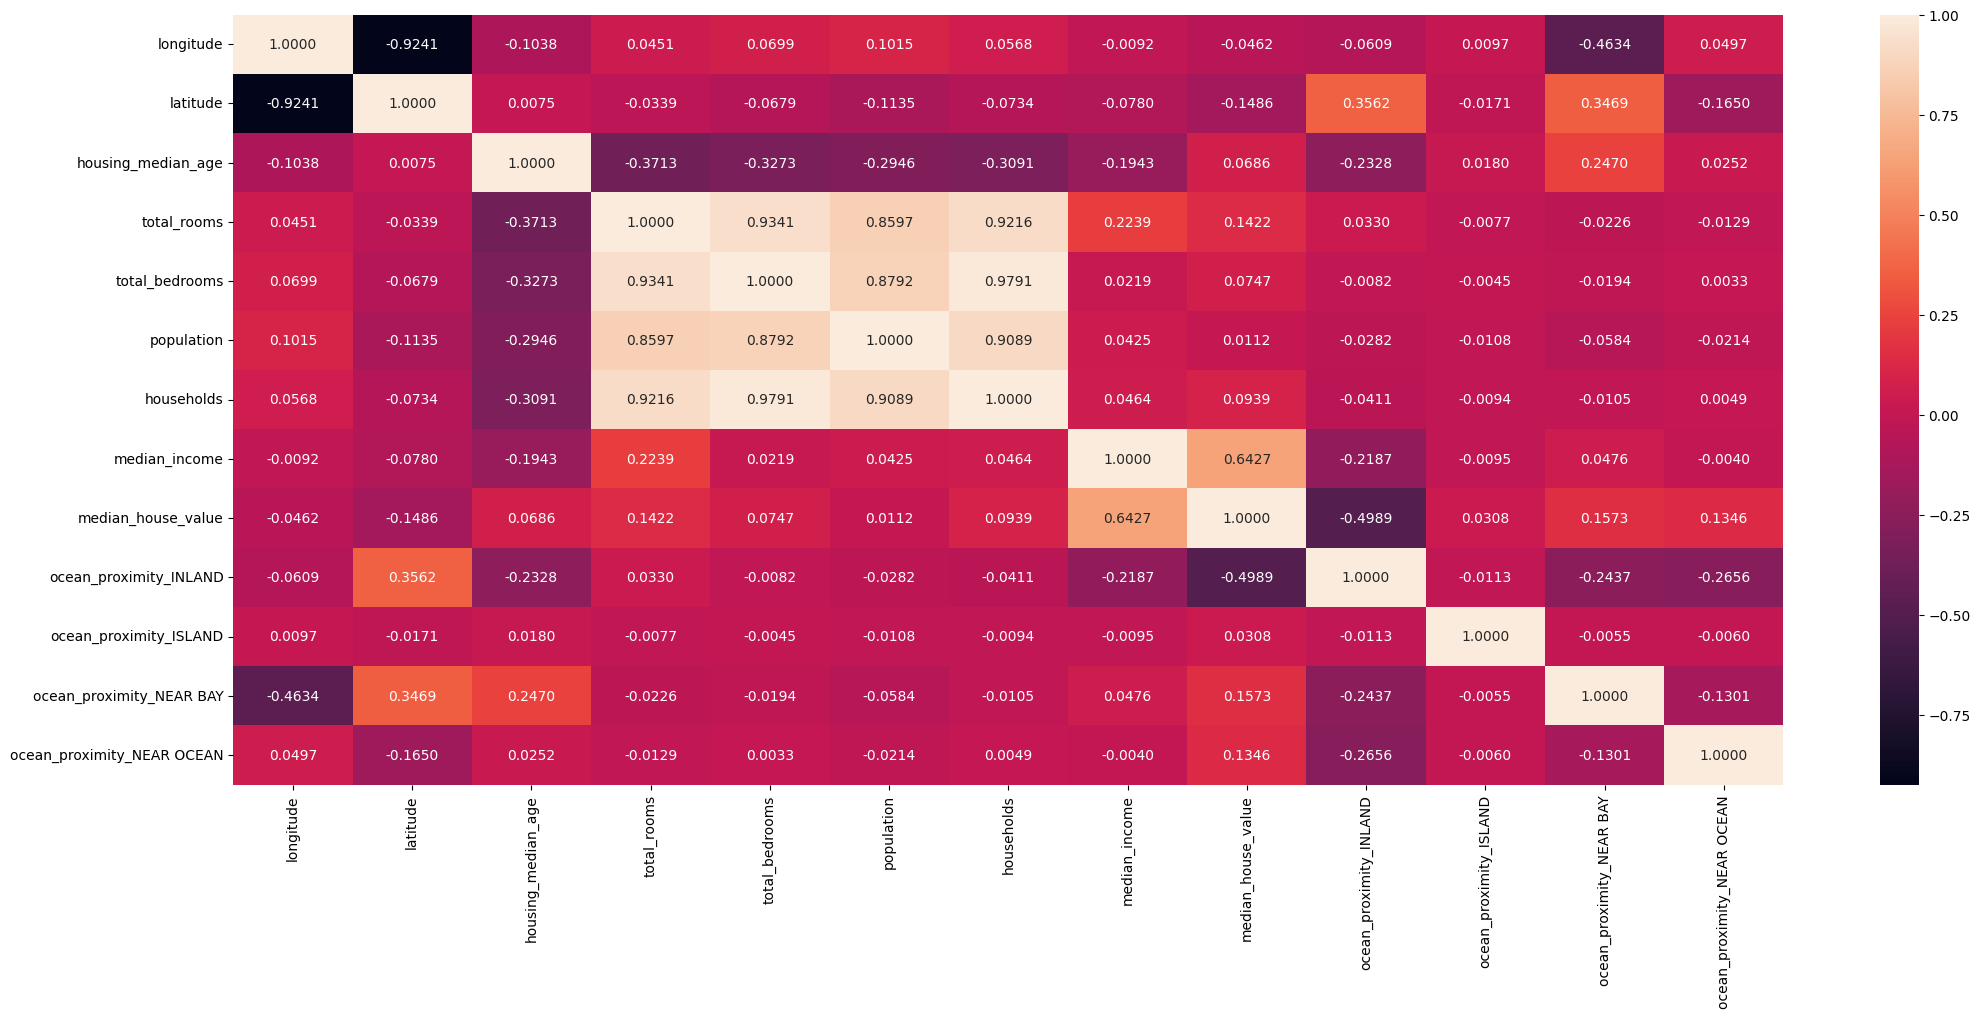

In [ ]:
#prima di procedere, vanno valutati eventuali problemi di multicollinearità tra le variabili indipendenti per evitare problemi di carattere inferenziale
# visualizziamoli con una heatmap
plt.figure(figsize=(25,10))
sns.heatmap(dati_con_dummy2.corr(), annot=True, fmt='.4f')

In [ ]:
#eseguiamo anche il VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = dati_con_dummy2[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'median_income',
                        'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
                        'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'total_bedrooms', 'population', 'households']]
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data["Variabile"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

                 Variabile          VIF
                     const 32810.448585
            total_bedrooms    37.013499
                households    34.482234
                  latitude    19.666528
                 longitude    17.713281
               total_rooms    14.028006
                population     6.533432
    ocean_proximity_INLAND     2.855082
             median_income     1.874591
  ocean_proximity_NEAR BAY     1.540852
        housing_median_age     1.367974
ocean_proximity_NEAR OCEAN     1.201836
    ocean_proximity_ISLAND     1.002282


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = dati_con_dummy2[['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'median_income',
                        'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
                        'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'population',]]  #abbiamo eliminato una ad una le variabili con vif oltre la soglia di 5 fino ad arrivare al risultato presentato
                                                                                                   # ci basiamo sul VIF per decidere quali variabili tenere nel modello
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data["Variabile"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

                 Variabile          VIF
                     const 32109.248349
                  latitude    19.403423
                 longitude    17.372831
               total_rooms     4.911390
                population     4.614150
    ocean_proximity_INLAND     2.797469
  ocean_proximity_NEAR BAY     1.539018
             median_income     1.357242
        housing_median_age     1.354534
ocean_proximity_NEAR OCEAN     1.201430
    ocean_proximity_ISLAND     1.001709


Decidiamo di tenere solamente le variabili "total rooms" e "population" per risolvere la multicollinearità con le variabili "households" "total bedrooms". Nonostante l'alta correlazione e VIF decidiamo di tenere le variabili spaziali latitudine e longitudine in quanto risulta poco sensato presentarle separatamente, la soluzione è sicuramente poco soddisfacente e va ad impattare in qualche modo la bontà del modello e dei loro coefficienti

In [ ]:
X=X.drop(['households', 'total_bedrooms'], axis=1) # Inizializziamo X escludendo le variabili da rimuovere
X

,longitude,latitude,housing_median_age,total_rooms,population,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,322.0,8.3252,0,0,1,0
1,-122.22,37.86,21.0,7099.0,2401.0,8.3014,0,0,1,0
2,-122.24,37.85,52.0,1467.0,496.0,7.2574,0,0,1,0
3,-122.25,37.85,52.0,1274.0,558.0,5.6431,0,0,1,0
4,-122.25,37.85,52.0,1627.0,565.0,3.8462,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,845.0,1.5603,1,0,0,0
20636,-121.21,39.49,18.0,697.0,356.0,2.5568,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,1007.0,1.7000,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,741.0,1.8672,1,0,0,0


In [ ]:
import statsmodels.api as sm   # osserviamo p value che indicano la significatività di ogni variabile con R^2 di 0,59
X = sm.add_constant(X)
modello = sm.OLS(Y, X).fit()
print(modello.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     2801.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        18:46:31   Log-Likelihood:            -2.4271e+05
No. Observations:               19475   AIC:                         4.854e+05
Df Residuals:                   19464   BIC:                         4.855e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

R-squared:                       0.590
Il modello spiega il 59% della varianza

In [ ]:
from sklearn.metrics import mean_absolute_error #calcoliamo il MAE del modello di regressione
previsioni = modello.predict(X)
mae = mean_absolute_error(Y, previsioni)
print(f"Mean Absolute Error (MAE): {mae:.2f} $")

Mean Absolute Error (MAE): 46305.60 $


l modello finale, presenta un Errore Assoluto Medio (MAE) di 46305.60 $
. Ciò significa che, nel prevedere il valore mediano delle case nei vari isolati della California, il modello si discosta in media di questa cifra dal valore reale.

   Prezzo Reale  Prezzo Predetto
0      452600.0    378757.579255
1      358500.0    398020.767315
2      352100.0    358148.421771
3      341300.0    302816.426855
4      342200.0    249211.118285
5      269700.0    249566.919500
6      299200.0    244234.498804
7      241400.0    232694.744891
8      226700.0    183576.119260
9      261100.0    248812.791955


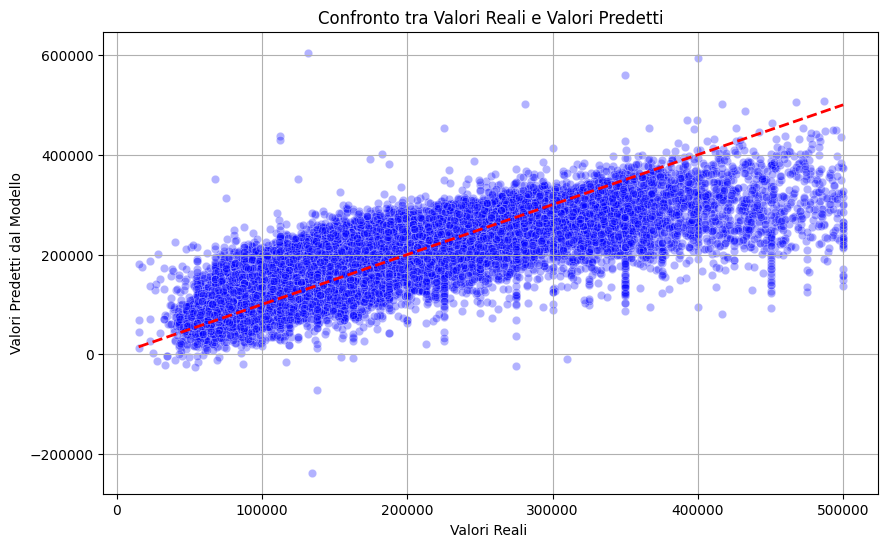

In [ ]:
confronto = pd.DataFrame({
    'Prezzo Reale': Y,
    'Prezzo Predetto': previsioni}) #visualizziamo in un data frame e in un grafico il confronto tra previsioni e prezzi reali
print(confronto.head(10))

plt.figure(figsize=(10, 6))

sns.scatterplot(x=Y, y=previsioni, alpha=0.3, color='blue')

plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', lw=2, linestyle='--')

plt.title('Confronto tra Valori Reali e Valori Predetti')
plt.xlabel('Valori Reali ')
plt.ylabel('Valori Predetti dal Modello')
plt.grid(True)

plt.show()

Il grafico mostra che il modello segue correttamente il trend reale, ma evidenzia limiti strutturali: la tendenza a sottostimare i prezzi delle case più costose, la presenza di eteroschedasticità con una maggiore dispersione degli errori verso destra e il calcolo di alcune previsioni outlier negative sotto zero dovuto ai vincoli della regressione lineare.

## Conclusioni: cosa fa salire il prezzo di una casa in California?

L'analisi esplorativa è stata condotta sul dataset California Housing, partito da 20.640 osservazioni e ridotto a 19.443 dopo la pulizia (rimozione di 207 NaN e di 965 case schiacciate sul cap artificiale di 500.001 $). Le visualizzazioni e la matrice di correlazione convergono nell'identificare due driver dominanti del prezzo, accompagnati da diversi fattori secondari di scarso impatto.

### Driver 1 — Il reddito mediano del quartiere (ρ = +0,643)

 È il fattore singolo più forte. Il regplot mostra una relazione chiaramente lineare: al crescere del reddito mediano del quartiere, il prezzo delle case sale in modo proporzionale. Passando da un reddito di 2 a un reddito di 10 (decine di migliaia di $), il prezzo previsto sale da 100000 a 500000 dollari
### Driver 2 — La posizione "costa vs entroterra" (ρ = −0,499 per INLAND)

Il secondo fattore più forte è di natura geografica. La mappa lat/long mostra che i prezzi alti si concentrano in tre cluster metropolitani costieri.


### Fattori secondari di impatto trascurabile

- Età della casa (ρ = +0,069): praticamente nulla. È questo il motivo per cui abbiamo scelto di non eliminare le case con il cap a 52 anni — la loro influenza sul prezzo è marginale.
- Numero di stanze del block group (ρ = +0,142), popolazione(+0,011), famiglie (+0,094), camere da letto (+0,075). Sono metriche complessive dei quartieri e dipendono più dalla dimensione di essi che dal valore delle singole case.
- Latitudine e longitudine prese singolarmente (ρ = −0,149 e −0,046): correlazioni deboli, ma fuorvianti se interpretate singolarmente. Interpretate insieme conducono a zone dove i prezzi delle case sono maggiori.  
### Risposta sintetica alla domanda di business

> *Cosa fa salire il prezzo di una casa in California?*
>
> Trovarsi in un quartiere ad alto reddito e vivere in un'area metropolitana costiera (Bay Area, Los Angeles o San Diego) anziché nell'entroterra. Questi due fattori, da soli, spiegano la maggior parte della variabilità dei prezzi nel dataset.

### Cosa ci dice il modello di regressione lineare?
Il modello di regressione lineare multipla quantifica in metriche monetarie le relazioni individuate, confermando le impressioni emerse dall'analisi esplorativa. Nel complesso, il modello spiega il 59% della variabilità dei prezzi delle case.

Isolando l'impatto netto di ciascun fattore, a parità di tutte le altre condizioni, i coefficienti indicano le seguenti variazioni sul prezzo delle case:

Il reddito medio del quartiere: trova piena conferma l'impressione che si tratti del driver principale. Per ogni incremento unitario nello scaglione di reddito medio del quartiere, il valore delle case sale mediamente di 32.190 dollari. Si tratta della variabile con il peso statistico maggiore all'interno del modello.

La posizione geografica rispetto alla costa: in questo modello, la categoria delle case situate a meno di un'ora dall'oceano è stata omessa e funge da base di riferimento per il confronto. I coefficienti delle altre zone indicano lo scostamento di prezzo rispetto a questa baseline:

Le case situate nell'entroterra registrano la penalizzazione maggiore, con una variazione negativa pari a 45.770 dollari in meno rispetto a quelle a meno di un'ora dall'oceano.

Gli immobili situati sulle isole presentano una variazione positiva pari a 165.000 dollari in più rispetto alla base di riferimento.

L'affaccio diretto sul mare aperto si associa a un incremento di 3.270 dollari, mentre le zone situate nei pressi della baia registrano una flessione di 4.631 dollari rispetto alla linea costiera di riferimento.

Le coordinate geografiche: i valori legati alla longitudine (meno 25.900 dollari per grado) e alla latitudine (meno 24.160 dollari per grado) confermano l'andamento diagonale osservato nei grafici, con un decremento dei prezzi man mano che ci si sposta verso il Nord o verso l'Est interno dello Stato.

### Limiti dell'analisi

- Il cap artificiale a 500.001 $ (presente nel dataset originale, da noi rimosso) indica che la fascia alta del mercato è sottorappresentata: il dataset non permette di analizzare il segmento delle case di lusso, dove i prezzi reali probabilmente arrivano a valori molto superiori.
- Molte variabili sono aggregate a livello di block group (non per singola casa): `total_rooms`, `total_bedrooms`, `population`, `households` sono totali del quartiere censuario. Per analisi future sarebbe utile derivare feature normalizzate (es. stanze per casa, persone per famiglia) che catturerebbero meglio le caratteristiche fisiche delle singole abitazioni.

- La regressione lineare presenta il limite di aver mantenuto latitudine e
  longitudine nel modello. Per quanto poco sensato presentarle singolarmente
  sono adottabili altre soluzioni per risolvere il problema della multicollinearità che abbiamo deciso di non adottare

